In [1]:
import torch
import torch.nn as nn

import matplotlib.pyplot as plt

from utils import get_device
from classifier_common import draw_images_with_score

In [ ]:
device = get_device()
print(device)

In [3]:
IMG_WIDTH = 48


class Reshape(nn.Module):
    def __init__(self, shape):
        super().__init__()
        self.shape = shape

    def forward(self, x):
        return torch.reshape(x, (x.size(0), *self.shape))


class Generator(nn.Module):
    def __init__(self, in_dim=100, out_dim=(IMG_WIDTH, IMG_WIDTH)):
        super(Generator, self).__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim

        self.layers = nn.Sequential(
            nn.Linear(in_dim, 128 * IMG_WIDTH * IMG_WIDTH),
            nn.BatchNorm1d(128 * IMG_WIDTH * IMG_WIDTH),
            nn.ReLU(),
            Reshape((128, IMG_WIDTH, IMG_WIDTH)),
            nn.ConvTranspose2d(128, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=5, padding=2),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.layers(x)

In [ ]:
z_dim = 100

G = Generator(in_dim=z_dim).to(device)
G.load_state_dict(torch.load("models/Gen.model", map_location=torch.device(device)))

In [5]:
class Decoder(nn.Module):
    def __init__(self, in_dim=100, out_dim=28):
        super(Decoder, self).__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim

        self.layers = nn.Sequential(
            nn.Linear(in_dim, 128 * self.out_dim // 8 * self.out_dim // 8),
            nn.BatchNorm1d(128 * self.out_dim // 8 * self.out_dim // 8),
            nn.LeakyReLU(0.2),
            Reshape((128, self.out_dim // 8, self.out_dim // 8)),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 1, kernel_size=7, padding=3),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.layers(x)


class Encoder(nn.Module):
    def __init__(self, in_dim=28, out_dim=100):
        super(Encoder, self).__init__()
        self.in_dim = in_dim

        self.layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
        )

        self.fc_mean = nn.Linear(128 * self.in_dim // 8 * self.in_dim // 8, out_dim)
        self.fc_logvar = nn.Linear(128 * self.in_dim // 8 * self.in_dim // 8, out_dim)

    def forward(self, x):
        h = self.layers(x)
        return self.fc_mean(h), self.fc_logvar(h)


class VAE(nn.Module):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def reparameterization(self, mean, std):
        epsilon = torch.randn_like(std).to(device)
        z = mean + std * epsilon
        return z

    def forward(self, x):
        mean, log_var = self.encoder(x)
        z = self.reparameterization(mean, torch.exp(0.5 * log_var))
        x_ = self.decoder(z)

        return x_, mean, log_var


In [ ]:
z_dim_vae = 48

encoder = Encoder(in_dim=IMG_WIDTH, out_dim=z_dim_vae)
decoder = Decoder(in_dim=z_dim_vae, out_dim=IMG_WIDTH)

vae = VAE(encoder=encoder, decoder=decoder).to(device)
vae.load_state_dict(torch.load("models/Vae.model", map_location=torch.device(device)))

In [7]:
class Classifier(nn.Module):
    def __init__(self, in_dim, out_dim):
        super(Classifier, self).__init__()

        self.in_dim = in_dim
        self.out_dim = out_dim

        self.layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(4608, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(100, out_dim),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.layers(x)

In [ ]:
classifier_art = Classifier(IMG_WIDTH * IMG_WIDTH, 8).to(device)
classifier_art.load_state_dict(
    torch.load("models/classifier_d8.model", map_location=torch.device(device))
)

In [9]:
def print_quality(img, rows, cols):
    fig, axes = plt.subplots(rows, cols, figsize=(1.5 * cols, 1.5 * rows))
    for row in range(rows):
        for col in range(cols):
            bear = img[row * cols + col][0]
            axes[row][col].imshow(bear)

            quality = img[row * cols + col][1]

            axes[row][col].title.set_text("%.4f" % quality)
            axes[row][col].axis("off")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

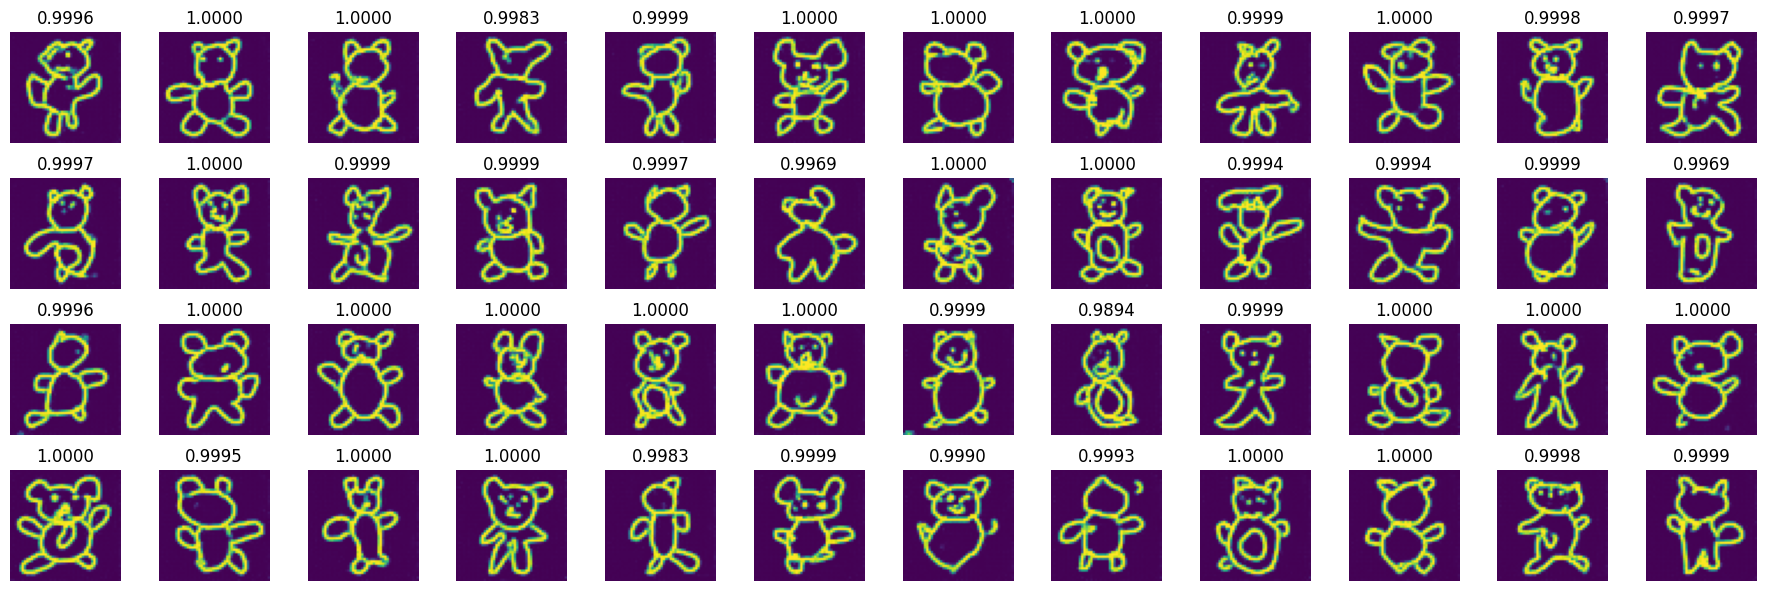

In [10]:
G.eval()
classifier_art.eval()

with torch.no_grad():
    z = torch.randn(4 * 12, z_dim).to(device)
    x_gen = G(z)
    quality_art = classifier_art(x_gen)[:, 0]
    x_gen = x_gen.cpu().view(-1, IMG_WIDTH, IMG_WIDTH)
    imgs_art = list(zip(x_gen, quality_art))

    print_quality(imgs_art, rows=4, cols=12)

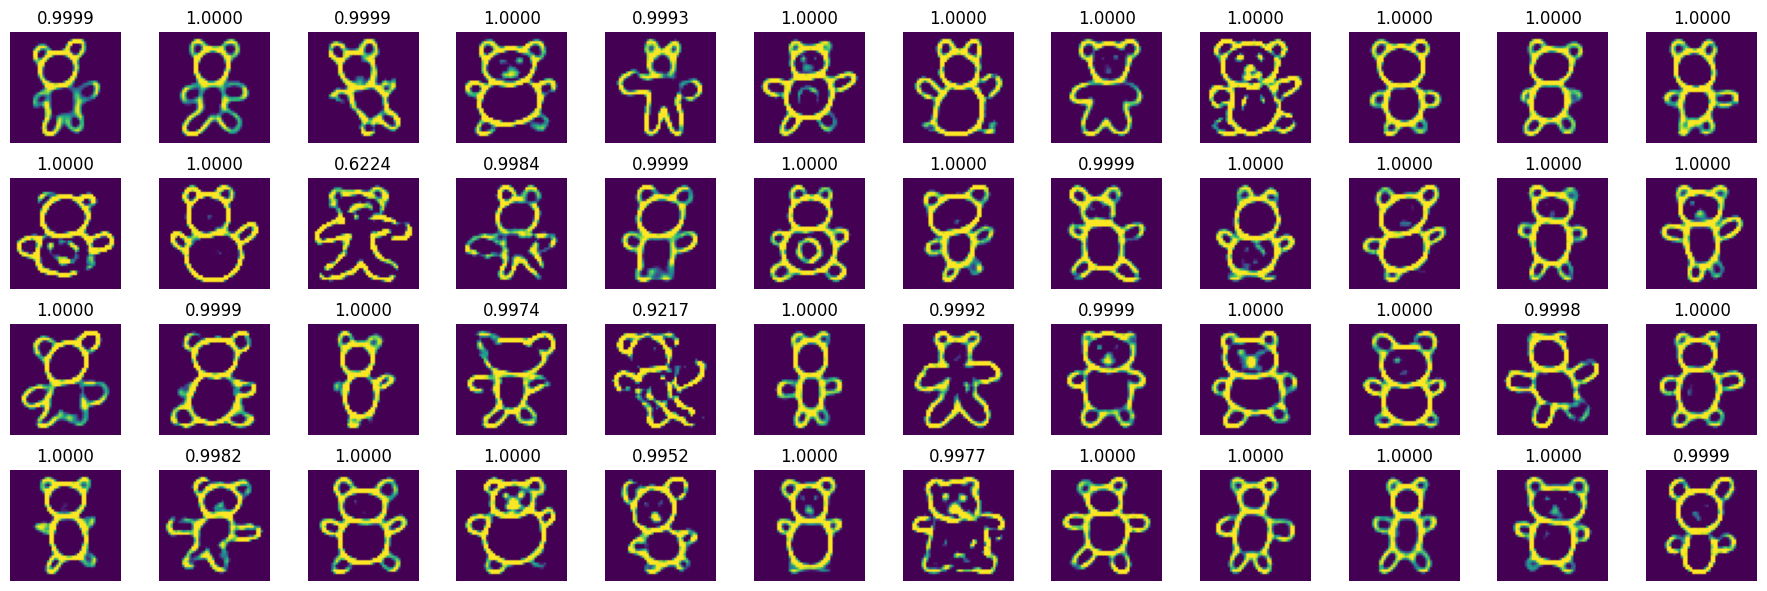

In [11]:
vae.eval()
classifier_art.eval()

with torch.no_grad():
    z = torch.randn(4 * 12, z_dim_vae).to(device)
    x_gen = vae.decoder(z)

    x_gen = (x_gen * 4).clamp(-1, 1)

    quality_art = classifier_art(x_gen)[:, 0]
    x_gen = x_gen.cpu().view(-1, IMG_WIDTH, IMG_WIDTH)
    imgs_art = list(zip(x_gen, quality_art))

    print_quality(imgs_art, rows=4, cols=12)

In [ ]:
import cv2
import numpy as np
import scipy


def tensors_to_video(tensors, video_path, fps, resize=None):
    def preprocess_frame(tensor):
        frame = tensor.detach().cpu().numpy()

        if frame.ndim == 3 and frame.shape[0] in (1, 3):
            frame = np.transpose(frame, (1, 2, 0))

        if frame.ndim == 3 and frame.shape[-1] == 1:
            frame = frame[..., 0]

        if frame.dtype != np.uint8:
            frame = frame.astype(np.float32)
            if frame.min() < 0:
                frame = (frame + 1.0) / 2.0
            frame = np.clip(frame, 0.0, 1.0)
            frame = (frame * 255.0).astype(np.uint8)

        if resize is not None:
            frame = cv2.resize(frame, resize, interpolation=cv2.INTER_LANCZOS4)

        if frame.ndim == 2:
            gray = frame.astype(np.float32)
            if gray.max() > 1.0:
                gray = gray / 255.0
            gray = np.clip(gray, 0.0, 1.0)
            frame = (plt.cm.viridis(gray)[..., :3] * 255.0).astype(np.uint8)
            frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        elif frame.ndim == 3 and frame.shape[-1] == 3:
            frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        else:
            raise ValueError(f"Unsupported frame shape: {frame.shape}")

        return frame

    out = None
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")

    for tensor in tensors:
        frame = preprocess_frame(tensor)

        if out is None:
            height, width = frame.shape[:2]
            out = cv2.VideoWriter(video_path, fourcc, fps, (width, height))

        out.write(frame)

    if out is not None:
        out.release()

In [18]:
def make_transitions_gan(tensors, intervals):
    G.eval()
    with torch.no_grad():
        res = [tensors[0]]
        for i in range(1, len(tensors) + 1):
            diff = (tensors[i % len(tensors)] - tensors[i - 1]) / (intervals - 1)

            for _ in range(intervals - 1):
                res.append(res[-1] + diff)

        pom = torch.stack(res)

        x_gen = G(pom).cpu()
        return x_gen


def make_transitions_vae(tensors, intervals):
    vae.eval()
    with torch.no_grad():
        res = [tensors[0]]
        for i in range(1, len(tensors) + 1):
            diff = (tensors[i % len(tensors)] - tensors[i - 1]) / (intervals - 1)

            for _ in range(intervals - 1):
                res.append(res[-1] + diff)

        pom = torch.stack(res)

        x_gen = vae.decoder(pom).cpu()
        x_gen = (x_gen * 4).clamp(-1, 1)
        return x_gen

In [28]:
def make_rand_tensors_gan(cnt, intervals, mini=0.8):
    while True:
        z = torch.randn(cnt, z_dim).to(device)
        tensors = make_transitions_gan(z, intervals)
        quality = (classifier_art(tensors.to(device))[:, 0]).min()
        print(quality)
        if quality >= mini:
            return tensors


def make_rand_tensors_vae(cnt, intervals, mini=0.8):
    while True:
        z = torch.randn(cnt, z_dim_vae).to(device)
        tensors = make_transitions_vae(z, intervals)
        quality = (classifier_art(tensors.to(device))[:, 0]).min()
        print(quality)
        if quality >= mini:
            return tensors

In [51]:
def make_transitions_circle(imgs, len, dim):
    res = torch.zeros((imgs, dim))
    for i in range(imgs):
        angle = torch.tensor([2 * torch.pi / imgs * i])
        res[i][0] = torch.cos(angle) * len
        res[i][1] = torch.sin(angle) * len
    return res


def make_good_circle_tensors_vae(cnt, intervals, mini=0.8):
    while True:
        tensors = make_transitions_circle(cnt * intervals, 5.0, z_dim_vae).to(device)
        rand_rot = (
            torch.tensor(scipy.stats.ortho_group.rvs(z_dim_vae)).float().to(device)
        )
        rand_shift = torch.randn(z_dim_vae).to(device)

        for i in range(len(tensors)):
            tensors[i] = rand_rot @ tensors[i] + rand_shift

        x_gen = vae.decoder(tensors)
        x_gen = (x_gen * 4).clamp(-1, 1)

        quality = (classifier_art(x_gen)[:, 0]).min()
        print(quality)
        if quality >= mini:
            return x_gen.cpu().detach()


def make_good_circle_tensors_gan(cnt, intervals, mini=0.8):
    while True:
        tensors = make_transitions_circle(cnt * intervals, 10.0, z_dim).to(device)
        rand_rot = torch.tensor(scipy.stats.ortho_group.rvs(z_dim)).float().to(device)
        rand_shift = torch.randn(z_dim).to(device)

        for i in range(len(tensors)):
            tensors[i] = rand_rot @ tensors[i] + rand_shift

        x_gen = G(tensors)

        quality = (classifier_art(x_gen)[:, 0]).min()
        print(quality)
        if quality >= mini:
            return x_gen.cpu().detach()

In [43]:
def make_merged_tensors(tensors, width, height):
    assert len(tensors) == width * height
    res = torch.zeros((len(tensors[0]), height * IMG_WIDTH, width * IMG_WIDTH))
    print(res.shape)
    for it in range(len(tensors[0])):
        kt = 0
        for i in range(height):
            for j in range(width):
                for ii in range(IMG_WIDTH):
                    res[it][i * IMG_WIDTH + ii][
                        j * IMG_WIDTH : j * IMG_WIDTH + IMG_WIDTH
                    ] = tensors[kt][it][0][ii]
                kt += 1
    return res

In [ ]:
fn = make_good_circle_tensors_vae
tensors = torch.stack([fn(8, 50, 0.99) for _ in range(4 * 4)])
res = make_merged_tensors(tensors, 4, 4)

In [ ]:
tensors_to_video(res, "outputs/video.mp4", 150, res.shape[1:])